In [1]:
import pandas as pd
import numpy as np

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [227]:
import sqlite3

conn = sqlite3.connect("../db.sqlite3")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()
[print(tab) for tab in tables]



('sqlite_sequence',)
('restaurant_orderitem',)
('restaurant_product',)
('restaurant_order',)


[None, None, None, None]

In [228]:
query = f"SELECT * FROM {tables[1][0]}"

df = pd.read_sql_query(query, conn)
df


,id,quantity,order_id,product_id
0,1,2,1,6
1,2,1,1,240
2,3,1,1,19
3,4,1,1,36
4,5,1,1,111
...,...,...,...,...
74813,74814,2,3255,247
74814,74815,2,12905,247
74815,74816,2,3272,247
74816,74817,1,11404,248


In [229]:
query = f"SELECT * FROM {tables[2][0]}"

df_products = pd.read_sql_query(query, conn)
df_products = df_products.rename(columns={"id": "product_id"})
df_products

,product_id,price,name
0,1,0.50,Mint Sauce
1,2,0.50,Lime Pickle
2,3,0.50,Mango Chutney
3,4,0.50,Red Sauce
4,5,0.50,Onion Chutney
...,...,...,...
243,244,12.95,King Prawn Karahi
244,245,12.95,Methi - King Prawn
245,246,12.95,Kurma
246,247,17.95,House Red wine 75cl


In [230]:
df = df.merge(df_products[["product_id", "price", "name"]], on="product_id", how="left")
df

,id,quantity,order_id,product_id,price,name
0,1,2,1,6,0.80,Plain Papadum
1,2,1,1,240,12.95,King Prawn Balti
2,3,1,1,19,2.95,Garlic Naan
3,4,1,1,36,3.95,Mushroom Rice
4,5,1,1,111,8.95,Paneer Tikka Masala
...,...,...,...,...,...,...
74813,74814,2,3255,247,17.95,House Red wine 75cl
74814,74815,2,12905,247,17.95,House Red wine 75cl
74815,74816,2,3272,247,17.95,House Red wine 75cl
74816,74817,1,11404,248,17.95,House white wine 75cl


In [233]:
query = f"SELECT * FROM {tables[3][0]}"

df_orders = pd.read_sql_query(query, conn, parse_dates=["datetime"])
df_orders.rename(columns={"id": "order_id", "datetime": "order_datetime"}, inplace=True)
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13397 entries, 0 to 13396
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        13397 non-null  int64         
 1   order_datetime  13397 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 209.5 KB


In [234]:
df_orders

,order_id,order_datetime
0,1,2019-08-03 20:25:00
1,2,2019-08-03 20:17:00
2,3,2019-08-03 20:09:00
3,4,2019-08-03 20:01:00
4,5,2019-08-03 19:44:00
...,...,...
13392,13393,2017-02-23 18:20:00
13393,13394,2016-10-23 16:03:00
13394,13395,2018-12-24 13:22:00
13395,13396,2017-08-31 12:20:00


In [235]:
df = df.merge(df_orders[["order_id", "order_datetime"]], on="order_id", how="left")
df

,id,quantity,order_id,product_id,price,name,order_datetime
0,1,2,1,6,0.80,Plain Papadum,2019-08-03 20:25:00
1,2,1,1,240,12.95,King Prawn Balti,2019-08-03 20:25:00
2,3,1,1,19,2.95,Garlic Naan,2019-08-03 20:25:00
3,4,1,1,36,3.95,Mushroom Rice,2019-08-03 20:25:00
4,5,1,1,111,8.95,Paneer Tikka Masala,2019-08-03 20:25:00
...,...,...,...,...,...,...,...
74813,74814,2,3255,247,17.95,House Red wine 75cl,2016-05-18 18:53:00
74814,74815,2,12905,247,17.95,House Red wine 75cl,2016-05-14 19:28:00
74815,74816,2,3272,247,17.95,House Red wine 75cl,2016-05-10 13:18:00
74816,74817,1,11404,248,17.95,House white wine 75cl,2016-04-07 19:04:00


In [236]:
df.shape[0]

74818

In [238]:
df.to_csv("../data/db_file.csv")

# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

In [239]:
popular_products = df.groupby("name")["quantity"].sum("Quantity").sort_values(ascending=False).head(10)
popular_products


name
Plain Papadum           10648
Pilau Rice               6367
Plain Naan               4983
Garlic Naan              3318
Plain Rice               2964
Onion Bhajee             2749
Mango Chutney            2504
Chicken Tikka Masala     2473
Chapati                  1935
Mint Sauce               1840
Name: quantity, dtype: int64

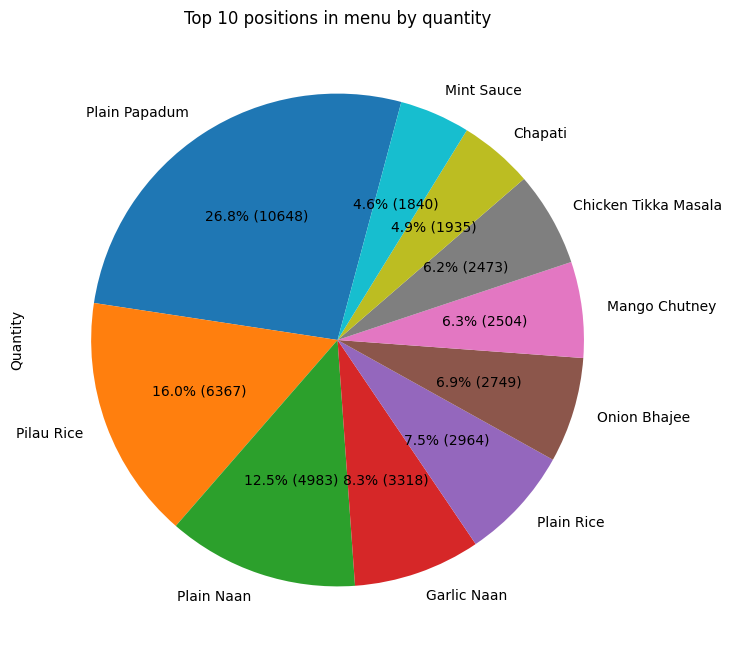

In [240]:
import matplotlib.pyplot as plt

def autopct_format(values):
    def inner(pct):
        total_sum = sum(values)
        val = int(round(total_sum / 100 * pct))
        return f"{pct:.1f}% ({val})"
    return inner

popular_products.plot.pie(figsize=(10, 8), autopct=autopct_format(popular_products.values), startangle=75)
plt.title("Top 10 positions in menu by quantity")
plt.ylabel("Quantity")
plt.show()

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

In [241]:
df["item_price"] = df["price"] * df["quantity"]
df.head(10)

,id,quantity,order_id,product_id,price,name,order_datetime,item_price
0,1,2,1,6,0.80,Plain Papadum,2019-08-03 20:25:00,1.60
1,2,1,1,240,12.95,King Prawn Balti,2019-08-03 20:25:00,12.95
2,3,1,1,19,2.95,Garlic Naan,2019-08-03 20:25:00,2.95
3,4,1,1,36,3.95,Mushroom Rice,2019-08-03 20:25:00,3.95
4,5,1,1,111,8.95,Paneer Tikka Masala,2019-08-03 20:25:00,8.95
5,6,1,1,3,0.50,Mango Chutney,2019-08-03 20:25:00,0.50
6,7,1,2,11,2.60,Plain Naan,2019-08-03 20:17:00,2.60
7,8,1,2,36,3.95,Mushroom Rice,2019-08-03 20:17:00,3.95
8,9,1,2,55,4.95,Tandoori Chicken (1/4),2019-08-03 20:17:00,4.95
9,10,1,2,98,7.95,Vindaloo - Lamb,2019-08-03 20:17:00,7.95


In [242]:
profitable_products = df.groupby("name")["item_price"].sum().sort_values(ascending=False).head(10)
profitable_products

name
Chicken Tikka Masala    22133.35
Pilau Rice              18782.65
Plain Naan              12955.80
Korma                   12261.50
Bombay Aloo             10894.45
Onion Bhajee            10858.55
Butter Chicken          10626.60
Garlic Naan              9788.10
Korma - Chicken          9764.45
Plain Rice               8743.80
Name: item_price, dtype: float64

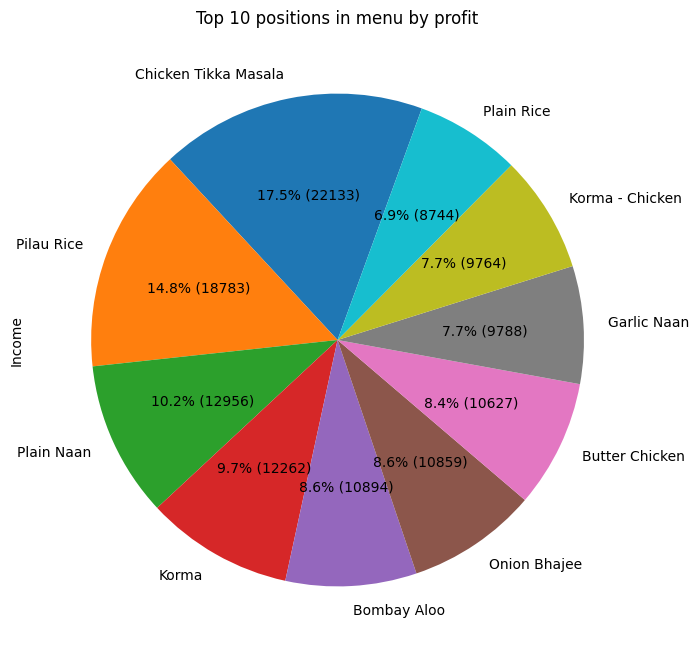

In [243]:
profitable_products.plot.pie(figsize=(10, 8), autopct=autopct_format(profitable_products.values), startangle=70)
plt.title("Top 10 positions in menu by profit")
plt.ylabel("Income")
plt.show()

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

In [244]:
df["order_hour"] = df["order_datetime"].dt.hour
df

,id,quantity,order_id,product_id,price,name,order_datetime,item_price,order_hour
0,1,2,1,6,0.80,Plain Papadum,2019-08-03 20:25:00,1.60,20
1,2,1,1,240,12.95,King Prawn Balti,2019-08-03 20:25:00,12.95,20
2,3,1,1,19,2.95,Garlic Naan,2019-08-03 20:25:00,2.95,20
3,4,1,1,36,3.95,Mushroom Rice,2019-08-03 20:25:00,3.95,20
4,5,1,1,111,8.95,Paneer Tikka Masala,2019-08-03 20:25:00,8.95,20
...,...,...,...,...,...,...,...,...,...
74813,74814,2,3255,247,17.95,House Red wine 75cl,2016-05-18 18:53:00,35.90,18
74814,74815,2,12905,247,17.95,House Red wine 75cl,2016-05-14 19:28:00,35.90,19
74815,74816,2,3272,247,17.95,House Red wine 75cl,2016-05-10 13:18:00,35.90,13
74816,74817,1,11404,248,17.95,House white wine 75cl,2016-04-07 19:04:00,17.95,19


In [245]:
orders_by_hours = df.groupby("order_hour")["item_price"].sum()
orders_by_hours

order_hour
0        177.95
1         54.65
2        199.25
3          8.90
4         63.45
5         57.40
6        121.60
8        447.70
9        570.60
10      1250.35
11      3807.05
12     10565.85
13      8282.65
14      3343.55
15      3781.70
16     15634.75
17     72110.20
18    132462.50
19    109045.05
20     50218.25
21     21480.30
22     11001.50
23       373.25
Name: item_price, dtype: float64

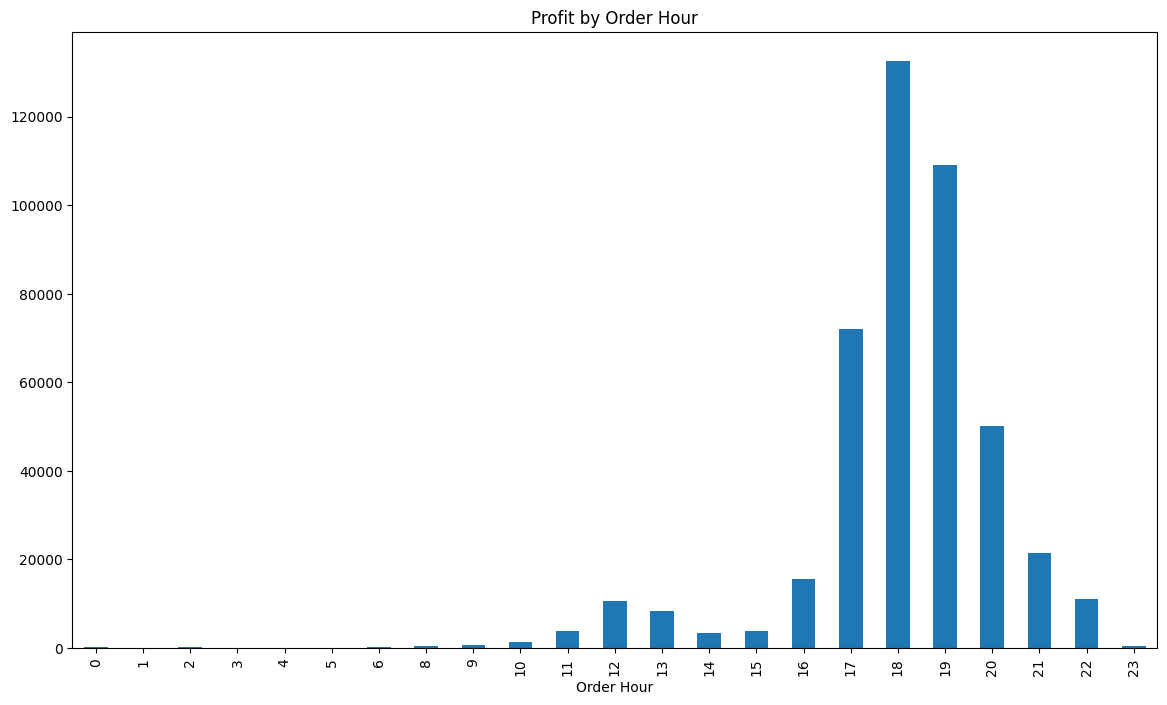

In [246]:
orders_by_hours.plot.bar(figsize=(14, 8))
plt.title("Profit by Order Hour")
plt.xlabel("Order Hour")
plt.show()

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

In [247]:
df["day_week"] = df["order_datetime"].dt.day_name()
df

,id,quantity,order_id,product_id,price,name,order_datetime,item_price,order_hour,day_week
0,1,2,1,6,0.80,Plain Papadum,2019-08-03 20:25:00,1.60,20,Saturday
1,2,1,1,240,12.95,King Prawn Balti,2019-08-03 20:25:00,12.95,20,Saturday
2,3,1,1,19,2.95,Garlic Naan,2019-08-03 20:25:00,2.95,20,Saturday
3,4,1,1,36,3.95,Mushroom Rice,2019-08-03 20:25:00,3.95,20,Saturday
4,5,1,1,111,8.95,Paneer Tikka Masala,2019-08-03 20:25:00,8.95,20,Saturday
...,...,...,...,...,...,...,...,...,...,...
74813,74814,2,3255,247,17.95,House Red wine 75cl,2016-05-18 18:53:00,35.90,18,Wednesday
74814,74815,2,12905,247,17.95,House Red wine 75cl,2016-05-14 19:28:00,35.90,19,Saturday
74815,74816,2,3272,247,17.95,House Red wine 75cl,2016-05-10 13:18:00,35.90,13,Tuesday
74816,74817,1,11404,248,17.95,House white wine 75cl,2016-04-07 19:04:00,17.95,19,Thursday


In [248]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

orders_by_day_of_week = df.groupby("day_week")["item_price"].sum().reindex(weekday_order)
orders_by_day_of_week

day_week
Monday        40008.30
Tuesday       38145.65
Wednesday     41246.20
Thursday      46021.55
Friday       100339.15
Saturday     112191.65
Sunday        67105.95
Name: item_price, dtype: float64

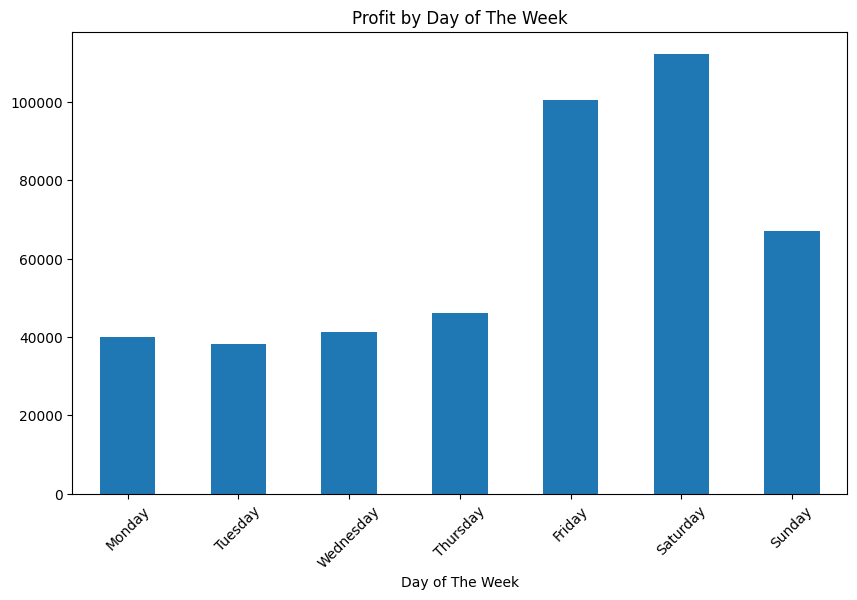

In [249]:
orders_by_day_of_week.plot.bar(figsize=(10, 6))
plt.title("Profit by Day of The Week")
plt.xlabel("Day of The Week")
plt.xticks(rotation=45)
plt.show()